<a href="https://colab.research.google.com/github/Piyush-Doshi/VOIS_AICTE_oct2025_Piyush/blob/main/Netflix_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('/content/Netflix Dataset.csv')
print(f"Dataset loaded: {len(df)} titles")

Dataset loaded: 7789 titles


In [8]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Release_Year'] = df['Release_Date'].dt.year

plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

category_distribution = df['Category'].value_counts()
movies_count = category_distribution['Movie']
tv_shows_count = category_distribution['TV Show']

In [9]:
print(f"Movies: {movies_count} ({movies_count/len(df)*100:.1f}%)")
print(f"TV Shows: {tv_shows_count} ({tv_shows_count/len(df)*100:.1f}%)")

Movies: 5379 (69.1%)
TV Shows: 2410 (30.9%)


In [10]:
category_by_year = df.groupby(['Release_Year', 'Category']).size().unstack(fill_value=0)

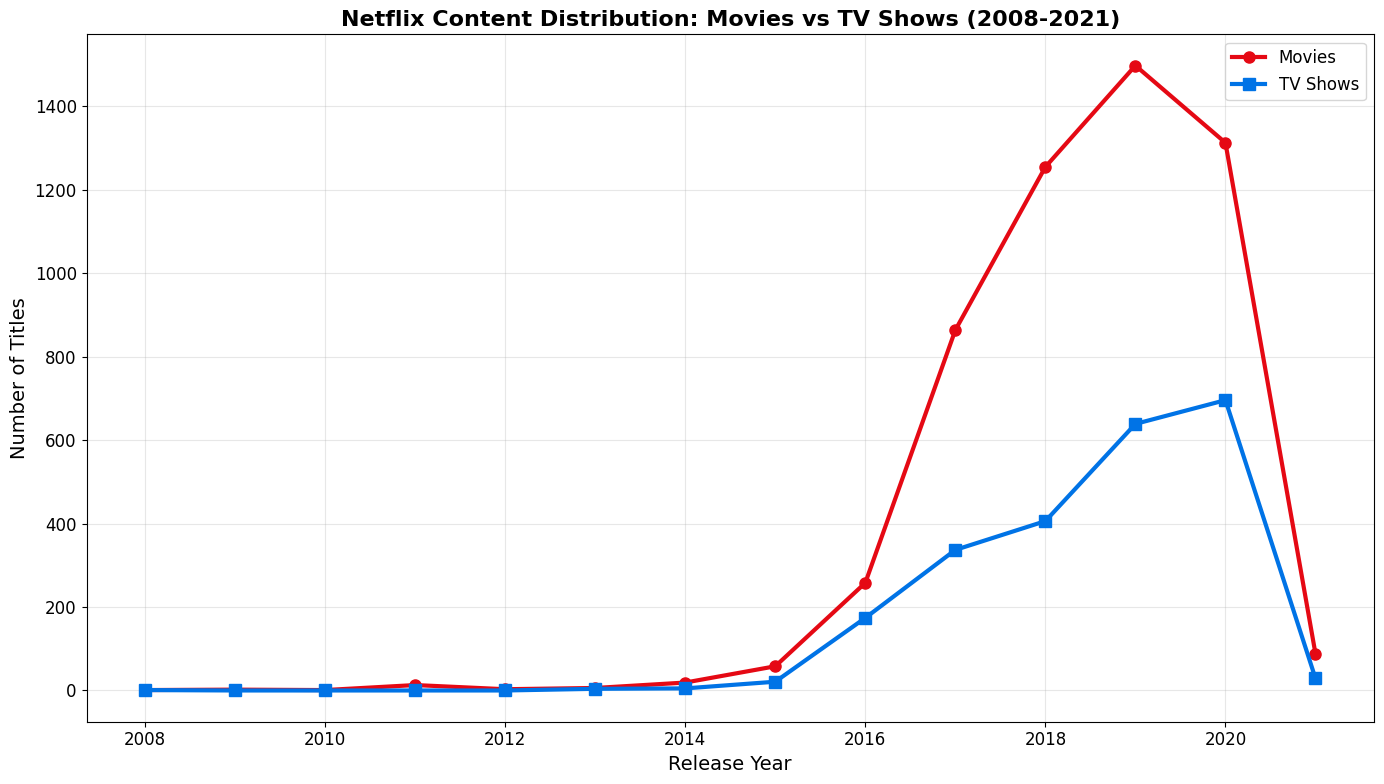

In [11]:
plt.figure(figsize=(14, 8))
plt.plot(category_by_year.index, category_by_year['Movie'], marker='o', linewidth=3, markersize=8, color='#E50914', label='Movies')
plt.plot(category_by_year.index, category_by_year['TV Show'], marker='s', linewidth=3, markersize=8, color='#0073E6', label='TV Shows')
plt.title('Netflix Content Distribution: Movies vs TV Shows (2008-2021)', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=14)
plt.ylabel('Number of Titles', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('movies_vs_tvshows_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
all_genres = []
for genres in df['Type'].dropna():
    genre_list = [genre.strip() for genre in genres.split(',')]
    all_genres.extend(genre_list)

genre_counts = Counter(all_genres)
top_15_genres = dict(genre_counts.most_common(15))

print("\nTop 15 Genres:")
for i, (genre, count) in enumerate(top_15_genres.items(), 1):
    print(f"{i:2d}. {genre}: {count}")

plt.figure(figsize=(12, 10))
genres = list(top_15_genres.keys())
counts = list(top_15_genres.values())
colors = plt.cm.viridis(np.linspace(0, 1, len(genres)))



Top 15 Genres:
 1. International Movies: 2437
 2. Dramas: 2108
 3. Comedies: 1472
 4. International TV Shows: 1199
 5. Documentaries: 786
 6. Action & Adventure: 721
 7. TV Dramas: 704
 8. Independent Movies: 675
 9. Children & Family Movies: 532
10. Romantic Movies: 531
11. TV Comedies: 525
12. Thrillers: 492
13. Crime TV Shows: 427
14. Kids' TV: 414
15. Docuseries: 353


<Figure size 1200x1000 with 0 Axes>

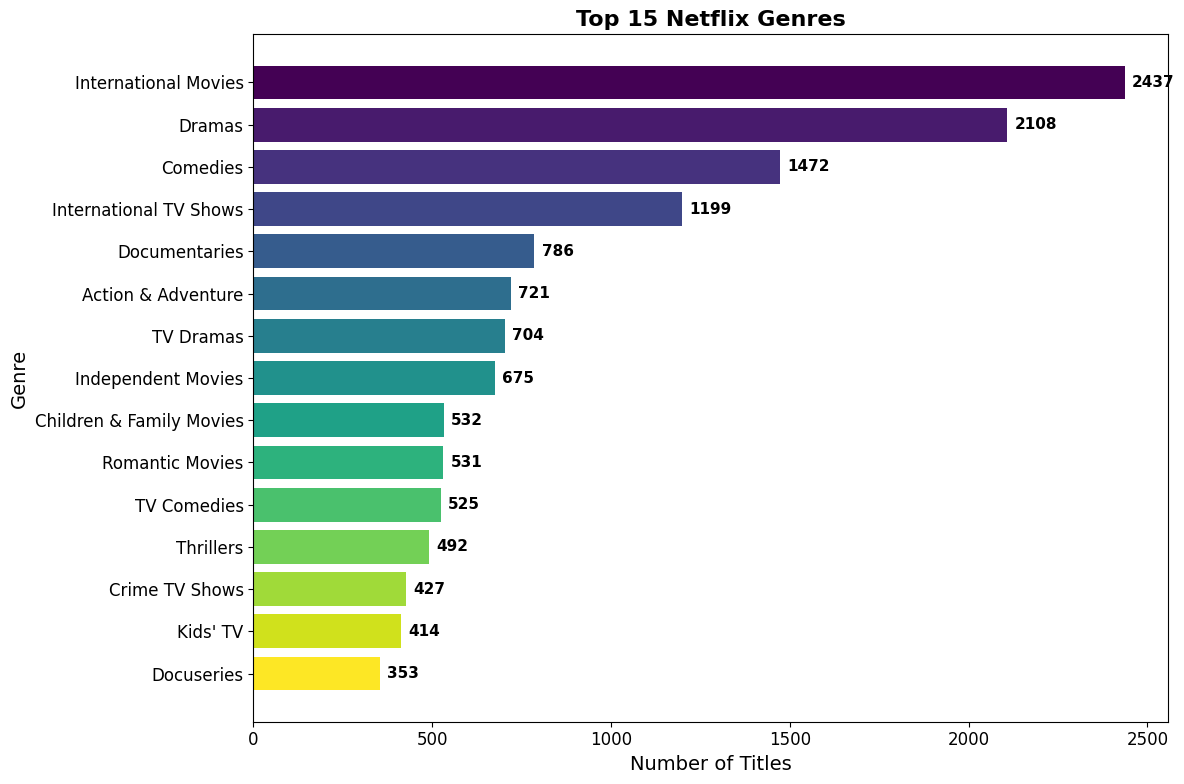

In [16]:
bars = plt.barh(genres, counts, color=colors)
plt.title('Top 15 Netflix Genres', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=14)
plt.ylabel('Genre', fontsize=14)
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             ha='left', va='center', fontsize=11, fontweight='bold')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_genres_chart.png', dpi=300, bbox_inches='tight')
plt.show()


In [17]:
all_countries = []
for countries in df['Country'].dropna():
    country_list = [country.strip() for country in countries.split(',')]
    all_countries.extend(country_list)

In [18]:
country_counts = Counter(all_countries)
top_10_countries = dict(country_counts.most_common(10))

In [19]:
print("\nTop 10 Countries:")
for i, (country, count) in enumerate(top_10_countries.items(), 1):
    print(f"{i:2d}. {country}: {count}")


Top 10 Countries:
 1. United States: 3298
 2. India: 990
 3. United Kingdom: 723
 4. Canada: 412
 5. France: 349
 6. Japan: 287
 7. Spain: 215
 8. South Korea: 212
 9. Germany: 199
10. Mexico: 154


In [20]:
plt.figure(figsize=(14, 8))
countries = list(top_10_countries.keys())
counts = list(top_10_countries.values())
colors = plt.cm.Reds(np.linspace(0.4, 1, len(countries)))

<Figure size 1400x800 with 0 Axes>

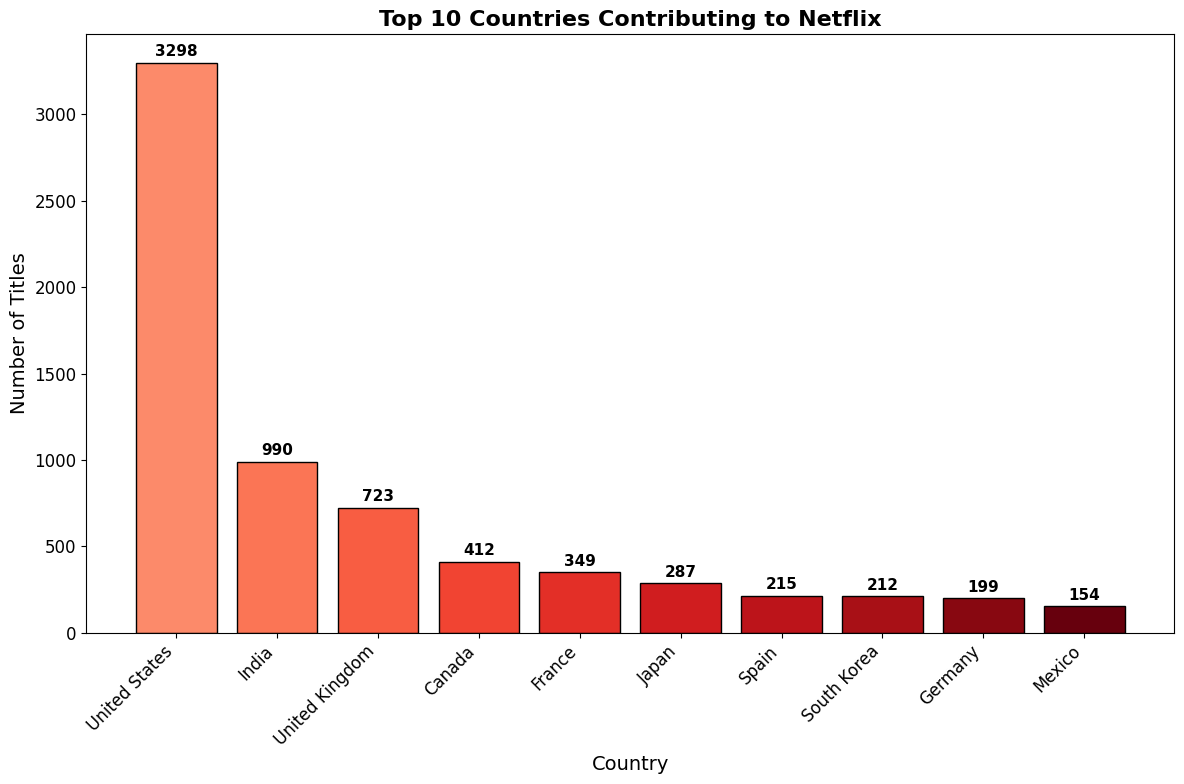

In [21]:
bars = plt.bar(countries, counts, color=colors, edgecolor='black', linewidth=1)
plt.title('Top 10 Countries Contributing to Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=14)
plt.ylabel('Number of Titles', fontsize=14)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('top_countries_chart.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
rating_dist = df['Rating'].value_counts()
print("\nTop 5 Ratings:")
for i, (rating, count) in enumerate(rating_dist.head(5).items(), 1):
    print(f"{i}. {rating}: {count} ({count/len(df)*100:.1f}%)")


Top 5 Ratings:
1. TV-MA: 2865 (36.8%)
2. TV-14: 1931 (24.8%)
3. TV-PG: 806 (10.3%)
4. R: 665 (8.5%)
5. PG-13: 386 (5.0%)


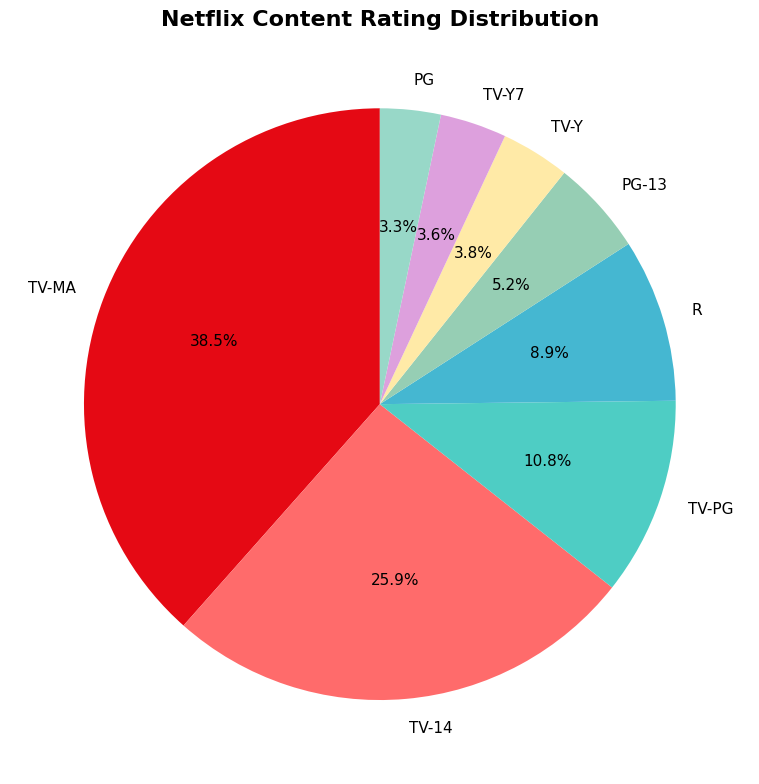

In [23]:
plt.figure(figsize=(10, 8))
top_ratings = rating_dist.head(8)
colors = ['#E50914', '#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']
wedges, texts, autotexts = plt.pie(top_ratings.values, labels=top_ratings.index, autopct='%1.1f%%',
                                  colors=colors, startangle=90, textprops={'fontsize': 11})
plt.title('Netflix Content Rating Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('rating_distribution_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
movies_df = df[df['Category'] == 'Movie'].copy()
movies_df['Duration_Minutes'] = movies_df['Duration'].str.extract(r'(\\d+)').astype(float)

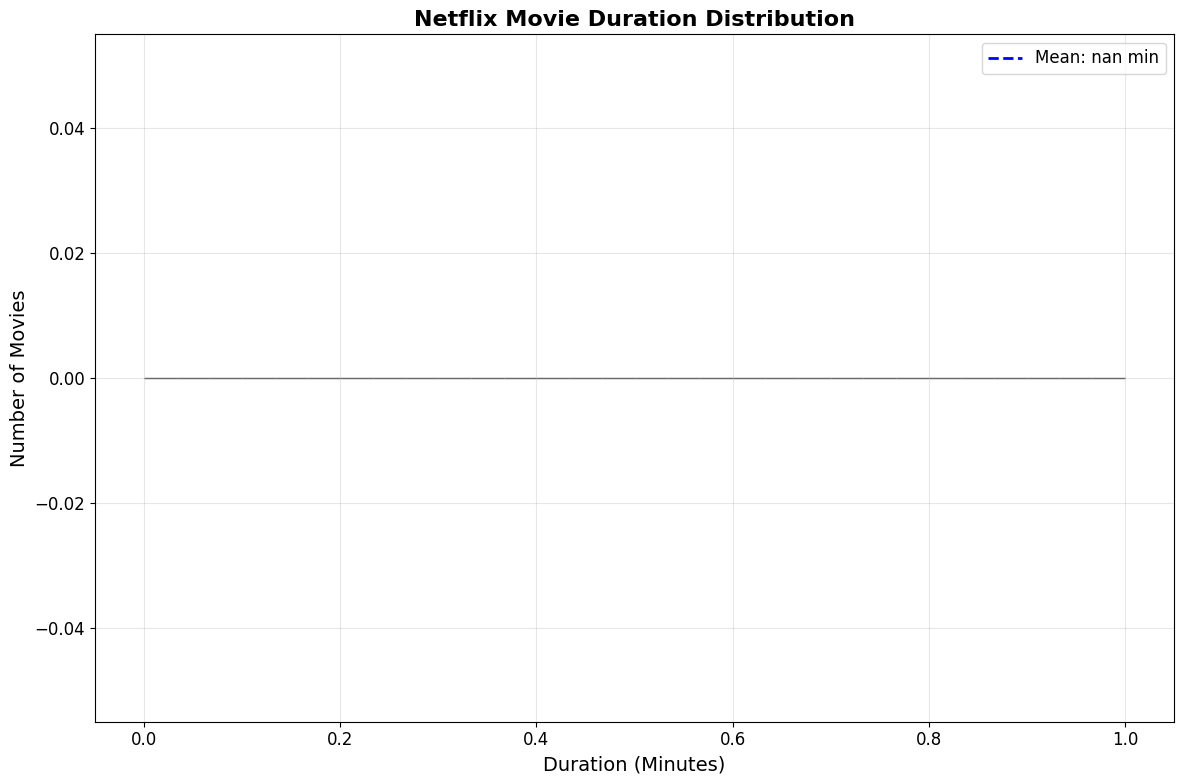

In [26]:
plt.figure(figsize=(12, 8))
plt.hist(movies_df['Duration_Minutes'].dropna(), bins=30, color='#E50914', alpha=0.7, edgecolor='black')
plt.axvline(movies_df['Duration_Minutes'].mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Mean: {movies_df["Duration_Minutes"].mean():.0f} min')
plt.title('Netflix Movie Duration Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Duration (Minutes)', fontsize=14)
plt.ylabel('Number of Movies', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('movie_duration_chart.png', dpi=300, bbox_inches='tight')
plt.show()
yearly_content = df.groupby('Release_Year').size()
peak_year = yearly_content.idxmax()


In [27]:
print(f"\nKey Findings:")
print(f"Peak year: {int(peak_year)} ({yearly_content.max()} titles)")
print(f"Average movie duration: {movies_df['Duration_Minutes'].mean():.1f} minutes")
print(f"Most common rating: {rating_dist.index[0]}")
print(f"Countries represented: {len(country_counts)}")
print(f"Total genres: {len(genre_counts)}")


Key Findings:
Peak year: 2019 (2137 titles)
Average movie duration: nan minutes
Most common rating: TV-MA
Countries represented: 118
Total genres: 42
